# The routing tables: topics, sources, sections

Three small files decide what the corpus can answer:

- `data/processed/topics.json` — the 20 curriculum topics, each with keywords
  and the sources assigned to it.
- `data/legal-sources/derived/statute-section-index.json` — 66 statutes broken
  into sections, each heading labelled with the source that supplied it.
- `data/legal-sources/derived/srilankalaw-sections.json` — one of the two
  republishers feeding that index, kept separately so it can be removed.

They form a chain: topic → source → section → case. A break anywhere in it is
invisible from either end, which is why they are worth reading together rather
than one at a time. Everything below is `candidate` or `unverified`; none of it
has been through a lawyer.

In [13]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parents[1] if Path.cwd().name == "commonlii" else Path.cwd()
PROCESSED = ROOT / "data/processed"
DERIVED = ROOT / "data/legal-sources/derived"

topics = json.loads((PROCESSED / "topics.json").read_text(encoding="utf-8"))
topic_sources = pd.read_csv(PROCESSED / "topic-sources.csv", dtype=str).fillna("")
registry = pd.read_csv(PROCESSED / "source-registry.csv", dtype=str).fillna("")
registry.columns = [c.strip('\ufeff"') for c in registry.columns]
section_index = json.loads((DERIVED / "statute-section-index.json").read_text(encoding="utf-8"))
srilankalaw = json.loads((DERIVED / "srilankalaw-sections.json").read_text(encoding="utf-8"))

print(f"topics.json              {len(topics)} topics, fields: {', '.join(topics[0])}")
print(f"source-registry.csv      {len(registry)} sources, {len(topic_sources)} topic-to-source rows")
print(f"statute-section-index    {len(section_index)} statutes, "
      f"{sum(len(v) for v in section_index.values())} sections")
print(f"srilankalaw-sections     {len(srilankalaw)} statutes, "
      f"{sum(len(v['sections']) for v in srilankalaw.values())} sections")

topics.json              20 topics, fields: topic_id, slug, name, purpose, status, keywords, sources
source-registry.csv      90 sources, 174 topic-to-source rows
statute-section-index    66 statutes, 5770 sections
srilankalaw-sections     20 statutes, 1105 sections


In [14]:
topic_frame = pd.DataFrame(
    [
        {"topic_id": t["topic_id"], "name": t["name"],
         "keywords": len(t["keywords"]), "sources": len(t["sources"]),
         "purpose_chars": len(t["purpose"]), "status_chars": len(t["status"])}
        for t in topics
    ]
).set_index("topic_id")
topic_frame

,name,keywords,sources,purpose_chars,status_chars
topic_id,,,,,
01,Introduction to Conveyancing,10,4,146,170
02,Registration of Documents,10,9,141,109
03,Registration of Title,10,7,160,175
04,Condominium Property,10,2,150,190
05,Formation of Deeds,10,24,125,148
06,Drafting and Study of Instruments,8,3,97,99
07,Stamping of Deeds,10,7,167,368
08,Duties of a Notary,10,4,155,69
09,Examination of Title,9,21,98,305


## Do the three copies of the mapping agree?

The topic-to-source mapping is written down three times: inside `topics.json`,
as rows in `topic-sources.csv`, and as a semicolon list in the `topics` column of
`source-registry.csv`. Three copies of one fact are three chances to drift, so
check rather than assume.

In [15]:
from_json = {(t["topic_id"], s["source_id"]) for t in topics for s in t["sources"]}
from_csv = set(map(tuple, topic_sources[["topic_id", "source_id"]].values))
from_registry = {
    (tid, r.source_id)
    for r in registry.itertuples()
    for tid in r.topics.split(";")
    if tid
}

print(f"pairs: json {len(from_json)} | topic-sources {len(from_csv)} | registry {len(from_registry)}")
print(f"json == topic-sources: {from_json == from_csv}")
print(f"json == registry:      {from_json == from_registry}")
print(f"registered but routed nowhere: {sorted(set(registry.source_id) - set(topic_sources.source_id))}")

pairs: json 174 | topic-sources 174 | registry 174
json == topic-sources: True
json == registry:      True
registered but routed nowhere: ['SRC088']


All three agree exactly. One registered source routes nowhere — the required
textbook bibliography, which is `bibliographic-only` and has no subject to belong
to. That is the tables being consistent with each other, which is not the same as
the routing being right.

## The keyword layer is prose, resliced

Each topic carries a `keywords` list, which reads like a retrieval aid. It is not
one. Every keyword in the file appears verbatim in that topic's own name or
purpose sentence, and most are single words lifted straight out of it — `modes`,
`charts`, `duties`, `rules`. Splitting a sentence does not produce search terms.
It produces the sentence again, in pieces.

In [16]:
keywords = [(t["topic_id"], k) for t in topics for k in t["keywords"]]
derived_from_prose = sum(
    k.lower() in f"{t['name']} {t['purpose']}".lower()
    for t in topics
    for k in t["keywords"]
)
single_word = sum(1 for _, k in keywords if " " not in k and "-" not in k)
shared = pd.Series([k for _, k in keywords]).value_counts()

print(f"keywords: {len(keywords)} across {len(topics)} topics, {shared.size} distinct")
print(f"appearing verbatim in their own name or purpose: {derived_from_prose}")
print(f"single words: {single_word}")
print(f"claimed by more than one topic: {(shared > 1).sum()}")
print(shared[shared > 1].to_string())

keywords: 182 across 20 topics, 157 distinct
appearing verbatim in their own name or purpose: 182
single words: 153
claimed by more than one topic: 18
registration    4
affecting       4
rules           4
statutory       3
acquisition     2
pedigree        2
inheritance     2
succession      2
land            2
transactions    2
transfers       2
authority       2
liability       2
checklist       2
property        2
drafting        2
statutes        2
reports         2


In [17]:
# What each keyword would actually match. A term that hits most of the corpus
# cannot route anything, whatever topic it is filed under.
judgments = pd.read_csv(ROOT / "data/commonlii/parsed/judgments.csv", dtype=str).fillna("")
body = judgments.text.str.lower()

reach = pd.DataFrame(
    [
        {"topic_id": tid, "keyword": k,
         "judgments_hit": int(body.str.contains(k.lower(), regex=False).sum())}
        for tid, k in keywords
    ]
)
reach["share"] = reach.judgments_hit / len(judgments)
print(f"keywords matching over half the corpus: {(reach.share > 0.5).sum()} of {len(reach)}")
print(f"keywords matching nothing:              {(reach.judgments_hit == 0).sum()}")
print("\nwidest:")
print(reach.nlargest(8, "judgments_hit")[["topic_id", "keyword", "share"]].to_string(index=False))
print("\nnarrowest that still hit something:")
narrow = reach[reach.judgments_hit > 0].nsmallest(8, "judgments_hit")
print(narrow[["topic_id", "keyword", "judgments_hit"]].to_string(index=False))

keywords matching over half the corpus: 8 of 182
keywords matching nothing:              22

widest:
topic_id    keyword    share
      18       case 0.951434
      18      title 0.682239
      05  necessary 0.642461
      02     proper 0.613321
      20 provisions 0.596207
      08     office 0.537928
      02       land 0.513414
      09       land 0.513414

narrowest that still hit something:
topic_id              keyword  judgments_hit
      01               charts              1
      04 condominium property              1
      15          trust deeds              1
      02           registries              2
      02               folios              2
      09            checklist              2
      11             nindagam              2
      13         conveyancing              2


## The source layer, and where the holes are

The `sources` list is the part carrying weight: it says which acquired statutes
back each topic. Joined against the registry it also says which ones are acquired
in name only. Sources are shared between topics, so these counts are not a
partition of the registry — the Prevention of Frauds Ordinance alone serves four
topics.

In [18]:
joined = topic_sources.merge(registry, on="source_id", how="left", validate="m:1")
coverage = joined.groupby("topic_id").agg(
    sources=("source_id", "nunique"),
    downloaded=("status", lambda s: (s == "downloaded").sum()),
    statutes=("source_type", lambda s: (s == "statute").sum()),
    gazettes=("source_type", lambda s: (s == "gazette").sum()),
)
coverage["name"] = [t["name"] for t in topics]
coverage["not_acquired"] = coverage.sources - coverage.downloaded
coverage.sort_values("sources", ascending=False)

,sources,downloaded,statutes,gazettes,name,not_acquired
topic_id,,,,,,
17,25,24,19,0,Drafting of Deeds,1
05,24,24,17,0,Formation of Deeds,0
09,21,18,16,0,Examination of Title,3
20,16,16,11,1,Criminal and Civil Liabilities of Notaries,0
12,12,12,12,0,State Lands,0
18,11,10,11,0,Other Related Statutory Laws,1
16,10,8,8,1,"Local Authority, UDA, and Other Regulations",2
02,9,8,3,0,Registration of Documents,1
03,7,5,1,5,Registration of Title,2


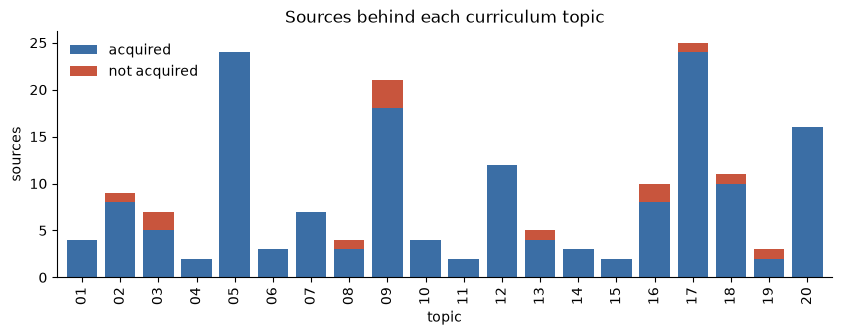

In [19]:
ax = coverage[["downloaded", "not_acquired"]].plot.bar(
    stacked=True, figsize=(10, 3.2), color=["#3b6ea5", "#c8553d"], width=0.8
)
ax.set_title("Sources behind each curriculum topic")
ax.set_xlabel("topic")
ax.set_ylabel("sources")
ax.legend(["acquired", "not acquired"], frameon=False)
ax.spines[["top", "right"]].set_visible(False)

In [20]:
hubs = topic_sources.source_id.value_counts()
print(f"sources serving more than one topic: {(hubs > 1).sum()} of {hubs.size}")
print(registry[registry.source_id.isin(hubs.head(5).index)]
      [["source_id", "official_title", "topics"]].to_string(index=False))

# The status field is free prose, and some of it is an admission.
hole = re.compile(r"still needs|not yet|needs a|pending|missing|no official", re.I)
print("\ntopics whose status text names a hole:")
for t in topics:
    if hole.search(t["status"]):
        print(f"  {t['topic_id']} {t['name']}: {' '.join(t['status'].split())[:110]}")

sources serving more than one topic: 49 of 89
source_id                                      official_title            topics
   SRC001                      Prevention of Frauds Ordinance       01;05;06;17
   SRC005                 Registration of Documents Ordinance       02;05;06;17
   SRC014                                  Notaries Ordinance    05;06;08;17;20
   SRC077 Registration of Old Deeds and Instruments Ordinance       02;09;17;18
   SRC081     Registrar General's Department guides and forms 02;03;08;09;13;17

topics whose status text names a hole:
  01 Introduction to Conveyancing: The Prevention of Frauds Ordinance and its 2022/2024 amendments are downloaded. The Matrimonial Rights and Inh
  03 Registration of Title: The main Act and four related gazette PDFs have been downloaded. Gazette 1302/16 is identified from the curric
  15 Trust Deeds: The 2018 amendment is downloaded from RGD. The base Trusts Ordinance still needs an official PDF.


## The shape of the mapping

Counts per topic hide the thing that matters here, which is that topics are not
separate piles of statutes — they overlap heavily, and the overlap is where a
routing decision gets made. The Notaries Ordinance serves five topics, the
Registrar General's guides six. Drawing the mapping shows which topics are
distinct subjects and which are views onto the same handful of statutes.

In [22]:
import html
from pathlib import Path

import numpy as np
import networkx as nx

from pyvis.network import Network
from IPython.display import IFrame, display

# =========================================================
# 1. Prepare the data
# =========================================================
sections_per_source = {
    source_id: len(sections)
    for source_id, sections in section_index.items()
}

title_of = dict(zip(
    registry["source_id"],
    registry["official_title"]
))

topic_name_of = {
    str(topic["topic_id"]): topic["name"]
    for topic in topics
}

# Keep statutes only
statute_ids = set(
    registry.loc[
        registry["source_type"].str.strip().str.lower().eq("statute"),
        "source_id"
    ].astype(str)
)

relations = (
    topic_sources[
        topic_sources["source_id"].astype(str).isin(statute_ids)
    ][["topic_id", "source_id"]]
    .drop_duplicates()
    .copy()
)

relations["topic_id"] = relations["topic_id"].astype(str)
relations["source_id"] = relations["source_id"].astype(str)

print(
    f"{relations['topic_id'].nunique()} topics · "
    f"{relations['source_id'].nunique()} statutes · "
    f"{len(relations)} relationships"
)

# Topics whose sources are all gazettes, guides or law reports drop out of a
# statutes-only graph. Say so, rather than letting them vanish quietly.
dropped = sorted(set(topic_sources["topic_id"].astype(str)) - set(relations["topic_id"]))
if dropped:
    print("no statute source, so absent below: "
          + "; ".join(f"{t} {topic_name_of.get(t, '')}" for t in dropped))

# =========================================================
# 2. Build the NetworkX graph
# =========================================================
G = nx.Graph()

for row in relations.itertuples(index=False):
    topic_id = row.topic_id
    source_id = row.source_id

    # Prefix node IDs to prevent ID collisions
    topic_node = f"topic::{topic_id}"
    statute_node = f"statute::{source_id}"

    G.add_node(
        topic_node,
        node_type="topic",
        original_id=topic_id,
        label=topic_name_of.get(topic_id, topic_id)
    )

    G.add_node(
        statute_node,
        node_type="statute",
        original_id=source_id,
        label=title_of.get(source_id, source_id),
        sections=sections_per_source.get(source_id, 0)
    )

    G.add_edge(
        topic_node,
        statute_node,
        relationship="COVERED_BY"
    )

# =========================================================
# 3. Create the interactive network
# =========================================================
net = Network(
    height="900px",
    width="100%",
    bgcolor="#f8fafc",
    font_color="#172033",
    notebook=True,
    cdn_resources="in_line",
    directed=False
)

# =========================================================
# 4. Add nodes
# =========================================================
for node, data in G.nodes(data=True):
    label = str(data.get("label", node))
    degree = G.degree(node)

    if data["node_type"] == "topic":
        net.add_node(
            node,
            label=label,
            title=(
                f"<b>Topic</b><br>"
                f"{html.escape(label)}<br>"
                f"Connected statutes: {degree}"
            ),
            color={
                "background": "#ef684a",
                "border": "#9f301f",
                "highlight": {
                    "background": "#ff8a6d",
                    "border": "#7f1d1d"
                }
            },
            size=min(22 + degree * 1.8, 50),
            shape="dot",
            borderWidth=2,
            font={
                "size": 18,
                "color": "#7c2d12",
                "face": "Arial",
                "strokeWidth": 4,
                "strokeColor": "#fff7ed"
            },
            group="topic"
        )

    else:
        sections = int(data.get("sections", 0))
        indexed = sections > 0

        net.add_node(
            node,
            label=label,
            title=(
                f"<b>Statute</b><br>"
                f"{html.escape(label)}<br>"
                f"Indexed sections: {sections}<br>"
                f"Connected topics: {degree}"
            ),
            color={
                "background": "#3983bd" if indexed else "#cbd5e1",
                "border": "#1d5279" if indexed else "#64748b",
                "highlight": {
                    "background": "#60a5fa",
                    "border": "#1e3a5f"
                }
            },
            size=min(10 + 1.2 * np.sqrt(sections), 35),
            shape="dot",
            borderWidth=1.5,
            font={
                "size": 13,
                "color": "#17324d",
                "face": "Arial",
                "strokeWidth": 4,
                "strokeColor": "#ffffff"
            },
            group=(
                "indexed_statute"
                if indexed
                else "unindexed_statute"
            )
        )

# =========================================================
# 5. Add topic-statute relationships
# =========================================================
for source, target, edge_data in G.edges(data=True):
    net.add_edge(
        source,
        target,
        title=edge_data.get("relationship", "COVERED_BY"),
        color={
            "color": "#94a3b8",
            "highlight": "#334155",
            "hover": "#334155",
            "opacity": 0.45
        },
        width=1.2,
        selectionWidth=3
    )

# =========================================================
# 6. Configure Neo4j-style physics
# =========================================================
net.set_options("""
{
  "interaction": {
    "hover": true,
    "tooltipDelay": 100,
    "navigationButtons": true,
    "keyboard": true,
    "multiselect": true,
    "hideEdgesOnDrag": true
  },
  "edges": {
    "smooth": {
      "enabled": true,
      "type": "continuous",
      "roundness": 0.15
    }
  },
  "physics": {
    "enabled": true,
    "solver": "forceAtlas2Based",
    "forceAtlas2Based": {
      "gravitationalConstant": -110,
      "centralGravity": 0.008,
      "springLength": 210,
      "springConstant": 0.045,
      "damping": 0.55,
      "avoidOverlap": 1
    },
    "stabilization": {
      "enabled": true,
      "iterations": 1500,
      "updateInterval": 50,
      "fit": true
    },
    "minVelocity": 0.6
  }
}
""")

# =========================================================
# 7. Save and display
# =========================================================
output_file = "topic-statute-knowledge-graph.html"

# pyvis 0.3.2 writes with open(name, "w+"), which resolves to cp1252 on Windows,
# and the inlined vis-network bundle is not cp1252-encodable. Build the HTML and
# write it in UTF-8 ourselves. net.show() has the same bug.
Path(output_file).write_text(
    net.generate_html(output_file, notebook=True),
    encoding="utf-8"
)
print(f"wrote {output_file} ({Path(output_file).stat().st_size / 1e6:.1f} MB)")

display(
    IFrame(
        src=output_file,
        width="100%",
        height="920px"
    )
)

19 topics · 57 statutes · 119 relationships
no statute source, so absent below: 19 Case Law on Conveyancing
wrote topic-statute-knowledge-graph.html (0.7 MB)


closest pairs:
  12  05 Formation of Deeds                 <-> 17 Drafting of Deeds
   9  05 Formation of Deeds                 <-> 20 Criminal and Civil Liabilities of Notaries
   7  05 Formation of Deeds                 <-> 09 Examination of Title
   7  07 Stamping of Deeds                  <-> 20 Criminal and Civil Liabilities of Notaries
   5  09 Examination of Title               <-> 17 Drafting of Deeds


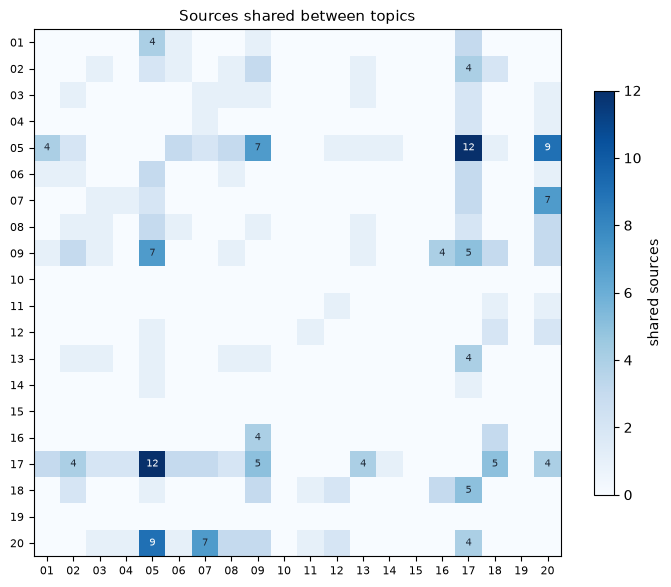

In [ ]:
# Which topics sit on the same statutes. The diagonal is blanked — a topic
# shares everything with itself, and it would swamp the scale.
membership = pd.crosstab(topic_sources.topic_id, topic_sources.source_id)
shared_matrix = membership.dot(membership.T).astype(int)
for tid in shared_matrix.index:
    shared_matrix.loc[tid, tid] = 0

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(shared_matrix, cmap="Blues")
ax.set_xticks(range(len(shared_matrix)), shared_matrix.columns, fontsize=8)
ax.set_yticks(range(len(shared_matrix)), shared_matrix.index, fontsize=8)
for i in range(len(shared_matrix)):
    for j in range(len(shared_matrix)):
        n = shared_matrix.iat[i, j]
        if n >= 4:
            ax.text(j, i, n, ha="center", va="center", fontsize=7,
                    color="white" if n > 8 else "#1f2937")
ax.set_title("Sources shared between topics", fontsize=11)
fig.colorbar(im, shrink=0.7, label="shared sources")

pairs = shared_matrix.stack()
pairs = pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)]
print("closest pairs:")
for (a, b), n in pairs.nlargest(5).items():
    print(f"  {n:>2}  {a} {coverage.loc[a, 'name'][:34]:<34} <-> {b} {coverage.loc[b, 'name']}")

## The section index

`statute-section-index.json` is the next link down: 66 statutes cut into
sections, each heading tagged with `heading_source` (who supplied the wording)
and `present_in` (who listed the section at all). Those two fields are what make
the index auditable — a section is not simply *there*, it is there because a
named source said so.

In [ ]:
sections = pd.DataFrame(
    [
        {"source_id": sid, "section": s["section"], "heading": s.get("heading", ""),
         "heading_source": s.get("heading_source", ""),
         "present_in": tuple(s.get("present_in", [])),
         "markers": len(s.get("amendment_markers", []))}
        for sid, secs in section_index.items()
        for s in secs
    ]
)
sections["n_sources"] = sections.present_in.map(len)

print(f"{len(sections)} sections across {sections.source_id.nunique()} statutes")
print(f"sections per statute: median {sections.groupby('source_id').size().median():.0f}, "
      f"max {sections.groupby('source_id').size().max()}")
print(f"\nheading supplied by:\n{sections.heading_source.value_counts().to_string()}")
print(f"\nlisted by:\n{sections.present_in.map(';'.join).value_counts().to_string()}")
print(f"\namendment markers: {sections.markers.sum()} on {(sections.markers > 0).sum()} sections")

5770 sections across 66 statutes
sections per statute: median 53, max 801

heading supplied by:
heading_source
legacy         2306
lawlanka       2232
srilankalaw    1105
none            127

listed by:
present_in
legacy                  2427
lawlanka                1142
legacy;lawlanka         1096
lawlanka;srilankalaw    1031
srilankalaw               74

amendment markers: 872 on 732 sections


Two sources corroborate each other on 2,127 sections. The other 3,643 rest on a
single source — a majority of the index is one republisher's word. `heading_source`
reads `none` on 127 sections, which is the honest case: the section number is
known and the heading is not.

The quality problems are in the headings, and they are visible without reading
the statutes.

In [ ]:
fragment = sections.heading.str.match(r"^[a-z]") | sections.heading.str.len().between(1, 12)
print(f"headings opening lowercase or under 12 characters: {fragment.sum()}")
print(sections[fragment].heading.head(6).tolist())

# A section number that is not a number is a parse failure wearing a number.
sections["number"] = sections.section.str.extract(r"^(\d+)").astype(float)
shape = sections.dropna(subset=["number"]).groupby("source_id").agg(
    found=("number", "size"), highest=("number", "max")
)
shape["density"] = shape.found / shape.highest
print(f"\nstatutes holding under 80% of their highest section number: "
      f"{(shape.density < 0.8).sum()} of {len(shape)}")
worst = shape.nsmallest(5, "density").join(
    registry.set_index("source_id").official_title
)
worst

headings opening lowercase or under 12 characters: 1146
['in case of', 'Repealed by', 'Day book', 'Caveats', 'Indexes', 'Evidence']

statutes holding under 80% of their highest section number: 5 of 66


,found,highest,density,official_title
source_id,,,,
SRC035,124,622299.0,0.000199,Western Province Financial Statute
SRC043,5,32.0,0.156250,Survey Act
SRC044,81,279.0,0.290323,Bank of Ceylon Ordinance
SRC076,30,58.0,0.517241,National Housing Act
SRC074,69,87.0,0.793103,State Mortgage and Investment Bank Law


The Western Province Financial Statute reports a highest section number of
622,299 against 124 sections found. Its section list holds `7777`, `12212`,
`77777` — page furniture and table digits read as section numbers. Any range
check built on `highest` is meaningless for that statute, and a citation
validator would accept nearly anything as in-range.

## What the free republisher contributes

`srilankalaw-sections.json` is one of the two structural sources, held separately
so the index can be rebuilt without it. It covers 20 statutes. Comparing it to
the merged index shows what it adds and, more usefully, where it is truncated:
two statutes where it returns a handful of sections against the other source's
full arrangement.

In [ ]:
compare = pd.DataFrame(
    [
        {"source_id": sid, "title": v["statute_title"],
         "srilankalaw": len(v["sections"]),
         "merged_index": len(section_index.get(sid, []))}
        for sid, v in srilankalaw.items()
    ]
)
compare["missing_from_srilankalaw"] = compare.merged_index - compare.srilankalaw
compare.sort_values("missing_from_srilankalaw", ascending=False)

,source_id,title,srilankalaw,merged_index,missing_from_srilankalaw
5,SRC091,Insolvency Ordinance,165,480,315
12,SRC101,Administration of Justice Law,4,55,51
1,SRC033,Land Reform Law,82,83,1
0,SRC028,Rent Act,52,52,0
3,SRC059,Trusts Ordinance,123,123,0
2,SRC048,Muslim Intestate Succession Ordinance,4,4,0
6,SRC092,Housing and Town Improvement Ordinance,114,114,0
4,SRC071,Prescription Ordinance,15,15,0
8,SRC096,Judicature Act,76,76,0
9,SRC097,Debt Conciliation Ordinance,67,67,0


The Administration of Justice Law is the clearest case: 4 sections from
srilankalaw, 55 in the merged index. Taking the smaller number at face value
would record a 55-section statute as a 4-section one, and every citation to
section 30 of it would come back `out-of-range` rather than `not-indexed`. This
is exactly the failure the two-source cross-check exists to catch.

## Where the chain breaks

Topic → source → section only holds if a statute is in both the registry and the
index. It is not always in both, and the break is silent from either side.

In [ ]:
registered = set(registry.source_id)
indexed = set(section_index)
unrouted = indexed - registered
registered_statutes = set(registry.loc[registry.source_type == "statute", "source_id"])

print(f"indexed but not in the registry: {len(unrouted)} statutes, "
      f"{sum(len(section_index[s]) for s in unrouted)} sections — no topic, so no routing")
print(f"registered statutes with no section index: {len(registered_statutes - indexed)}")

topic_of = {r.source_id: r.topics for r in registry.itertuples()}
per_topic = pd.Series(
    [tid for sid in indexed & registered for tid in topic_of[sid].split(";") if tid]
).value_counts().rename("indexed_statutes")
structure = coverage[["name", "sources"]].join(per_topic).fillna(0)
structure["indexed_statutes"] = structure.indexed_statutes.astype(int)
structure

indexed but not in the registry: 22 statutes, 1534 sections — no topic, so no routing
registered statutes with no section index: 13


,name,sources,indexed_statutes
topic_id,,,
01,Introduction to Conveyancing,4,2
02,Registration of Documents,9,1
03,Registration of Title,7,1
04,Condominium Property,2,1
05,Formation of Deeds,24,16
06,Drafting and Study of Instruments,3,3
07,Stamping of Deeds,7,5
08,Duties of a Notary,4,1
09,Examination of Title,21,13


topic_id
05    2139
09    1929
17    1503
16     977
20     695

topics reaching no indexed section: ['19']


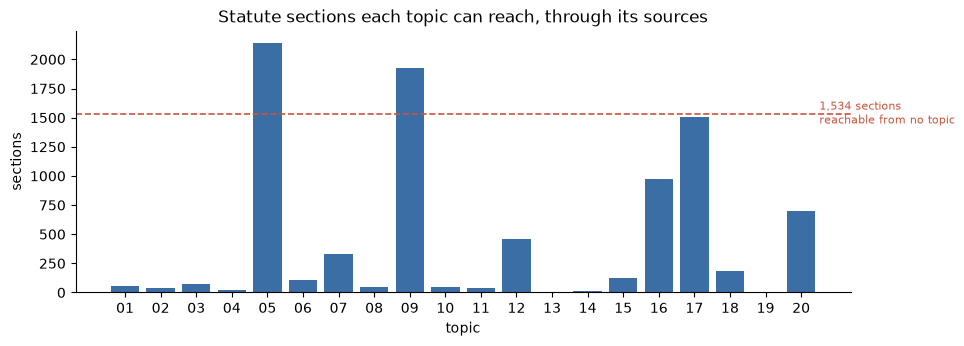

In [ ]:
# Sections reachable from each topic. Shared statutes are counted once per
# topic they serve, so these sum to more than 5,770 — this is reach, not a
# partition of the index.
reach_sections = (
    topic_sources.assign(n=topic_sources.source_id.map(sections_per_source))
    .fillna({"n": 0})
    .groupby("topic_id").n.sum()
    .reindex(sorted(row))
)
unrouted_sections = sum(
    n for sid, n in sections_per_source.items() if sid not in set(topic_sources.source_id)
)

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(reach_sections.index, reach_sections.values, color="#3b6ea5", width=0.8)
ax.axhline(unrouted_sections, color="#c8553d", lw=1.2, ls="--")
ax.text(19.4, unrouted_sections, f" {unrouted_sections:,} sections\n reachable from no topic",
        color="#c8553d", fontsize=8, va="center")
ax.set_title("Statute sections each topic can reach, through its sources")
ax.set_xlabel("topic")
ax.set_ylabel("sections")
ax.spines[["top", "right"]].set_visible(False)

print(reach_sections.astype(int).sort_values(ascending=False).head(5).to_string())
print(f"\ntopics reaching no indexed section: "
      f"{sorted(reach_sections[reach_sections == 0].index.tolist())}")

More sections sit outside the mapping than all but three topics can reach. The
red line is the 1,534 unrouted sections; only topics 05, 09 and 17 clear it.

At the other end, three topics reach almost nothing indexed. Topic 13 (Power of
Attorney) and 14 (Last Wills) rest on short statutes — the Wills Ordinance has 9
sections — so their small bars are honest. Topic 19 reaches nothing because its
sources are law-report series, which have no sections to index. A statute-section
answer for wills or powers of attorney has very little text behind it, and that
is a property of the law, not a fault in the pipeline.

## How the tables route in practice

`legal-case-index/case_topic_links.csv` is the chain doing its job: links from a
case to a curriculum topic, each made by resolving a statute the case cites and
following that statute's topic assignment. Every link is a `candidate`.

In [ ]:
links = pd.read_csv(PROCESSED / "legal-case-index/case_topic_links.csv", dtype=str).fillna("")
routing = links.groupby("topic_id").agg(links=("case_id", "size"), cases=("case_id", "nunique"))
routing = routing.reindex(coverage.index).fillna(0).astype(int)
routing["name"] = coverage.name
routing["sources"] = coverage.sources
print(f"{len(links)} links | {links.case_id.nunique()} distinct cases | "
      f"review status: {links.review_status.unique().tolist()}")
routing.sort_values("links", ascending=False)

10527 links | 3023 distinct cases | review status: ['candidate']


,links,cases,name,sources
topic_id,,,,
05,3231,2477,Formation of Deeds,24
17,2546,2137,Drafting of Deeds,25
09,2288,2071,Examination of Title,21
18,535,527,Other Related Statutory Laws,11
06,400,353,Drafting and Study of Instruments,3
20,354,331,Criminal and Civil Liabilities of Notaries,16
12,256,208,State Lands,12
01,243,238,Introduction to Conveyancing,4
15,220,220,Trust Deeds,2


Traffic concentrates where sources concentrate: topics 05, 09 and 17 hold twenty
or more statutes each and take most of the links, so a case citing a common
procedural statute lands there by default. That is the statute count talking, not
the subject of the case.

Topic 19, *Case Law on Conveyancing*, receives none. That is structural rather
than a gap: its sources are the law-report series themselves, and a case does not
cite the series it is printed in. Any coverage report built off this table has to
say so, or the same false hole gets rediscovered every time.

## Against the conveyancing gate

`scripts/classify_commonlii_conveyancing.py` sorts the same 2,162 judgments by
subject vocabulary and knows nothing about these tables — it reads catchwords and
body text, while the link table reads statute citations. Two unrelated methods
over the same cases, so the agreement is worth measuring.

In [ ]:
gate_path = ROOT / "evaluation/runs/conveyancing-gate-v1/conveyancing_labels.csv"
assert gate_path.exists(), "run scripts/classify_commonlii_conveyancing.py first"

gate = pd.read_csv(gate_path, dtype=str).fillna("")
gate["topic_linked"] = ("commonlii-" + gate.case_id).isin(set(links.case_id))
agreement = gate.groupby("verdict").topic_linked.agg(cases="size", linked="sum", share="mean")
agreement.loc[["required", "review", "not-required"]]

,cases,linked,share
verdict,,,
required,246,124,0.504065
review,155,51,0.329032
not-required,1761,50,0.028393


In [ ]:
# Which curriculum topics the cases Draftly needs actually land on.
required_ids = set("commonlii-" + gate.loc[gate.verdict == "required", "case_id"])
hit = links[links.case_id.isin(required_ids)].groupby("topic_id").case_id.nunique()
supported = pd.DataFrame({"required_cases": hit}).reindex(coverage.index).fillna(0).astype(int)
supported["name"] = coverage.name
supported["sources"] = coverage.sources
supported.sort_values("required_cases", ascending=False)

,required_cases,name,sources
topic_id,,,
05,90,Formation of Deeds,24
17,77,Drafting of Deeds,25
09,56,Examination of Title,21
20,33,Criminal and Civil Liabilities of Notaries,16
06,26,Drafting and Study of Instruments,3
11,21,"Temple, Devala, Nindagam, Sangika, and Pudgali...",2
18,19,Other Related Statutory Laws,11
01,19,Introduction to Conveyancing,4
15,16,Trust Deeds,2


## What this says

The tables are in better shape than the keyword list suggests. The three copies
of the topic mapping agree exactly, the source layer is real and mostly acquired,
the section index labels every heading with who supplied it, and the whole chain
routes ten thousand case links without contradicting itself.

Five things to act on, in the order they block work:

1. **22 indexed statutes are not in the registry**, so 1,534 sections belong to
   no topic and cannot be routed to. They are the index-only statutes waiting on
   an official PDF; until they are registered they are invisible to anything that
   walks topic → source → section.
2. **The Western Province Financial Statute's section numbering is unusable** —
   highest "section" 622,299. Any range check against it passes everything.
3. **A majority of sections rest on one source.** 3,643 of 5,770 have no second
   listing, so the cross-check that caught the Administration of Justice Law
   (4 sections against 55) is not available for most of the index.
4. **The keywords are not a routing signal.** All 182 are verbatim slices of
   their own topic's prose, 153 of them single words. Eight match more than half
   the case corpus, 22 match none of it, and 18 are claimed by two topics or
   more. Author them against real subject vocabulary — the gate's term lists are
   a starting point — or drop the field so nothing downstream reads it as one.
5. **Topic 19 is a container, not a subject.** Mark it, so its permanent zero
   stops reading as a gap.

Every link here is `candidate` and every gate verdict is `unverified`. Two
unverified methods agreeing is corroboration, not measurement.